Euler Approximation when h = 0.1 ------> 2.0370359763344877e-10
The current error is: ------> 0.5166555576322874
The Accumulated error is: 0.5166555576322874 

Euler Approximation when h = 0.15000000000000002 ------> 5.976826389415572e-11
The current error is: ------> 0.4918806226596191
The Accumulated error is: 0.4918806226596191 

Euler Approximation when h = 0.20000000000000004 ------> 1.3471354624412646e-11
The current error is: ------> 0.48391953155063316
The Accumulated error is: 0.48391953155063316 

Euler Approximation when h = 0.25000000000000006 ------> 1.8189894035458407e-12
The current error is: ------> 0.4925488936905867
The Accumulated error is: 0.4925488936905867 

Euler Approximation when h = 0.30000000000000004 ------> 7.378697629483768e-14
The current error is: ------> 0.533531877666512
The Accumulated error is: 0.533531877666512 

Euler Approximation when h = 0.3500000000000001 ------> 2.287679245496063e-15
The current error is: ------> 0.530452295329411
The Accumula

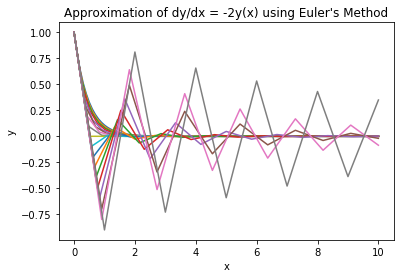

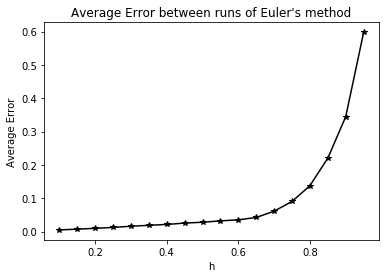

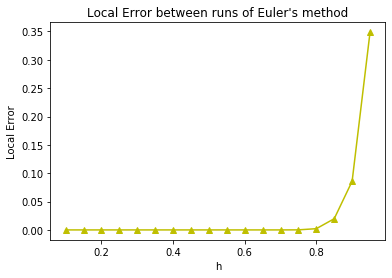

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Function representing dy/dx = -2y
def f(x, y):
    return -2 * y
x_start, x_end = 0, 10

#Empty lists to store error and h values
average_errors = []
local_errors = []
h_stored = []
lam = lambda x: -2*np.cos(x)
plt.figure(1)
# Defining parameters
for h in np.arange(0.1, 1, 0.05):
    num_steps = int((x_end - x_start) / h)
    accumulated_error = 0
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    running_error = np.zeros(num_steps + 1)                     
    y_values[0] = 1 # y(0) = 1

    # Implement Euler's method
    for i in range(num_steps):       
        y_values[i + 1] = y_values[i] + h *f(x_values[i], y_values[i])
        current_exact = np.exp(-2 * (x_values[i + 1]))
        current_error = abs(current_exact - y_values[i + 1])
        accumulated_error += current_error 
        running_error[i + 1] = accumulated_error
    #Finding the local error for each run    
    index = np.argmin(np.abs(x_values - 10)) 
    y_approx = y_values[index]
    y_exact = np.exp(-2 *(x_values[index]))
    local_error = abs(y_exact - y_approx)
    
    local_errors.append(local_error)
    average_error = accumulated_error/num_steps                           
    h_stored.append(h)
    average_errors.append(average_error)
                               
    plt.plot(x_values, y_values)
    print(f"Euler Approximation when h = {h}","------>", y_values[-1])
    print("The current error is:","------>", running_error[-1] )
    print(f"The Accumulated error is: {accumulated_error}", '\n')
        

# Plot the results                              
#Euler approximation
print("---Euler Approximation---", '\n')
plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2y(x) using Euler's Method")

#Average error vs h
plt.figure(2)
plt.plot(h_stored, average_errors, color = 'k', marker = '*')
plt.xlabel('h')
plt.ylabel('Average Error')
plt.title("Average Error between runs of Euler's method")
plt.show() 

#Local error vs h
plt.figure(3)
plt.plot(h_stored, local_errors, color = 'y', marker = '^')
plt.xlabel('h')
plt.ylabel('Local Error')
plt.title("Local Error between runs of Euler's method")
plt.show() 
              